## Centroid-Based concept vectors
This notebook uses the activations collected by the script `generate_contrastive_activations.py` to compute centroid-based concept vectors, first for 36 colored shapes and then for their 6 colors.

In [1]:
model_name = 'gemma' #'qwen', 'intern' or 'gemma'
recreate_conc_vectors = False # If true, recreates concept vectors from scratch
                              # true requires running generate_contrastive_activations.py first

#### Import and utilities

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from ast import literal_eval # to get dict/list from csv
import pickle
import hydra
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams['figure.constrained_layout.use'] = True 

import pyrootutils,sys
pyrootutils.setup_root('.',cwd=True,pythonpath=False)
sys.path.append('./src')

In [3]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize("config")
cfg = hydra.compose("activations_gen", overrides=[dict(qwen='+experiment=bal_qwen7b',
                                                       intern='+experiment=bal_internvl8b',
                                                       gemma='+experiment=bal_gemma12b')[model_name],
                                                  ])
probelabel = 'mmp' #layer used to read hidden activations (defined in config)

/tmp/ipykernel_2619972/3837993164.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize("config")


In [4]:
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()
marker_shapes = ["\U000025A0","\U000025B2","\U000025CF","\U00002B1F","\U00002605","\U00002764"]

def simmatrix(V):
  'returns a matrix of cosine similarities'
  n=V.shape[0]
  sims = torch.empty(n,n)
  for i in range(n):
    sims[i]=torch.cosine_similarity(V,V[i])
  return sims

In [5]:
## Define colors and shapes
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()
marker_shapes = ["\U000025A0","\U000025B2","\U000025CF","\U00002B1F","\U00002605","\U00002764"]

In [6]:
## Plot vector similarities and their distributions
samecol = []
sameshape = []
different = []
for i in range(36):
  for j in range(i):
    if (i//6) == (j//6):
      samecol.append(i*36+j)
    elif i%6 == (j%6):
      sameshape.append(i*36+j)
    else:
      different.append(i*36+j)

labellist = []
for color in colors:
  for shape in shapes:
    labellist.append(color[:3]+' '+shape[:3])
def plotsims(sims, template_label=None, model_name = None):
  plt.close('all')
  fig,ax = plt.subplots(dpi=300,figsize=(6,7),
                        nrows = 2,height_ratios=(6,1),
                        layout='tight')
  
  fig.tight_layout(h_pad=.1)
  markerlabels = []
  for i in range(6):
    for j in range(6):
      markerlabels.append(f'${marker_shapes[j]}$')
      ax[0].scatter(i*6+j+0.5,36.8,s=50,
                    clip_on=False,
                    marker=f'${marker_shapes[j]}$',
                    color=[c/255. for c in cfg.dataset.COLORS_DICT[colors[i]]])
      ax[0].scatter(-0.8,i*6+j+0.5,s=50,
                    clip_on=False,
                    marker=f'${marker_shapes[j]}$',
                    color=[c/255. for c in cfg.dataset.COLORS_DICT[colors[i]]])
  simsfl = sims.flatten()
  kwargs = dict(bins=100,range=(-1.,1.),density=True)


  ax[1].hist(simsfl[samecol],label='Same color',**kwargs,alpha=0.4,edgecolor='C0')
  ax[1].hist(simsfl[sameshape],label='Same shape',**kwargs,alpha=0.4,edgecolor='C1')
  ax[1].hist(simsfl[different],label='Both different',**kwargs,alpha=0.4,edgecolor='C2')

  ax[1].hist(simsfl[samecol],histtype='step',**kwargs,edgecolor='C0',linewidth=1.)
  ax[1].hist(simsfl[sameshape],histtype='step',**kwargs,edgecolor='C1',linewidth=1.)
  ax[1].hist(simsfl[different],histtype='step',**kwargs,edgecolor='C2',linewidth=1.)
  ax[1].set_xlim(-1,1)
  ax[1].set_xticklabels([])
  ax[1].tick_params(axis='both', which='both', length=0, labelleft=False)
  ax[1].legend(loc='upper left')
  ax[1].grid(False)
  
  cax = ax[1].inset_axes([0.,-.23,1,.15])
  sns.heatmap(sims,
              square=True,
              vmin=-1,vmax=1,
              linewidths=0.05,
              cbar=True, cbar_ax=cax,
              cbar_kws=dict(orientation='horizontal',label='Cosine similarity'),
              cmap='vlag',ax=ax[0])
  cax.xaxis.set_ticks_position('both')
  for spine in cax.spines.values():
    spine.set_visible(True)
    spine.set_lw(0.5)
  for spine in ax[0].spines.values():
    spine.set_visible(True)
    spine.set_lw(0.5)

  ax[0].set_yticks(torch.arange(36)+0.5,[])
  ax[0].set_xticks(torch.arange(36)+0.5,[])
  tempnicelabel= {
    'centroid':'Centroid-Based',
    'probe PCA':'Probe-Based (PCA)',
    'probe': 'Probe-Based (Raw)'
  }[template_label]
  nicename = {
    "qwen": 'Qwen 2.5 7B',
    'intern':'InternVL 2.5 8B',
    'gemma': 'Gemma 3 12B'
  }[model_name]
  ax[0].set_title(f'{nicename} - {tempnicelabel} Concept Vectors')

  return fig,ax

#### Compute or load concept vectors

In [7]:
if recreate_conc_vectors:
  templatedir = os.path.join('.',"outputs",cfg.model.model_name,
                          'bin_class','data_templates_81')

  pos = pd.read_csv(os.path.join(templatedir,'pos.txt'),header=None).values

  with open(os.path.join(templatedir,'activations_mmp.pkl'),'rb') as f:
    activations = pickle.load(f)
  
  def pos_to_indexes(pos):
    row = pos[0].item()//28 #valid for all three models 
    col = pos[1].item()//28
    return [(row-1)*16+col-1,(row-1)*16+col,row*16+col-1,row*16+col]
  actens = torch.zeros(6,6,81,4,activations['redsquare'][0].shape[-1],dtype=torch.double)
  # color×shape×target_pos×token×emb_size
  for i,col in enumerate(cfg.dataset.COLORS):
    for j,sha in enumerate(cfg.dataset.SHAPES):
      for p in range(81):
        actens[i,j,p,:,:] = activations[col+sha][p].squeeze()[pos_to_indexes(pos[p%9]),:]
  act = actens.flatten(end_dim=1).flatten(start_dim=1,end_dim=2)
  
  class_avg = act.mean(dim=1)
  glob_avg = act.mean(dim=(0,1)).unsqueeze(0)
  conc_vectors = F.normalize(class_avg-glob_avg,dim=1)
  datapath = os.path.join('.','outputs',cfg.model.model_name)
  if not os.path.exists(datapath):
    os.makedirs(datapath)
  torch.save(conc_vectors.to(torch.float),
            os.path.join(datapath,f'colorshape_cv_centroid.pt'))
  
  color_avg = actens.mean(dim=(1,2,3))
  color_cv = F.normalize(color_avg-glob_avg,dim=1)
  torch.save(color_cv.to(torch.float),
           os.path.join(datapath,f'color_cv_centroid.pt'))
else:
  datapath = os.path.join('.','outputs',cfg.model.model_name)
  conc_vectors = torch.load(os.path.join(datapath,f'colorshape_cv_centroid.pt'))
  color_cv = torch.load(os.path.join(datapath,f'color_cv_centroid.pt'))


#### Similarity plot

In [8]:
sims = simmatrix(conc_vectors)

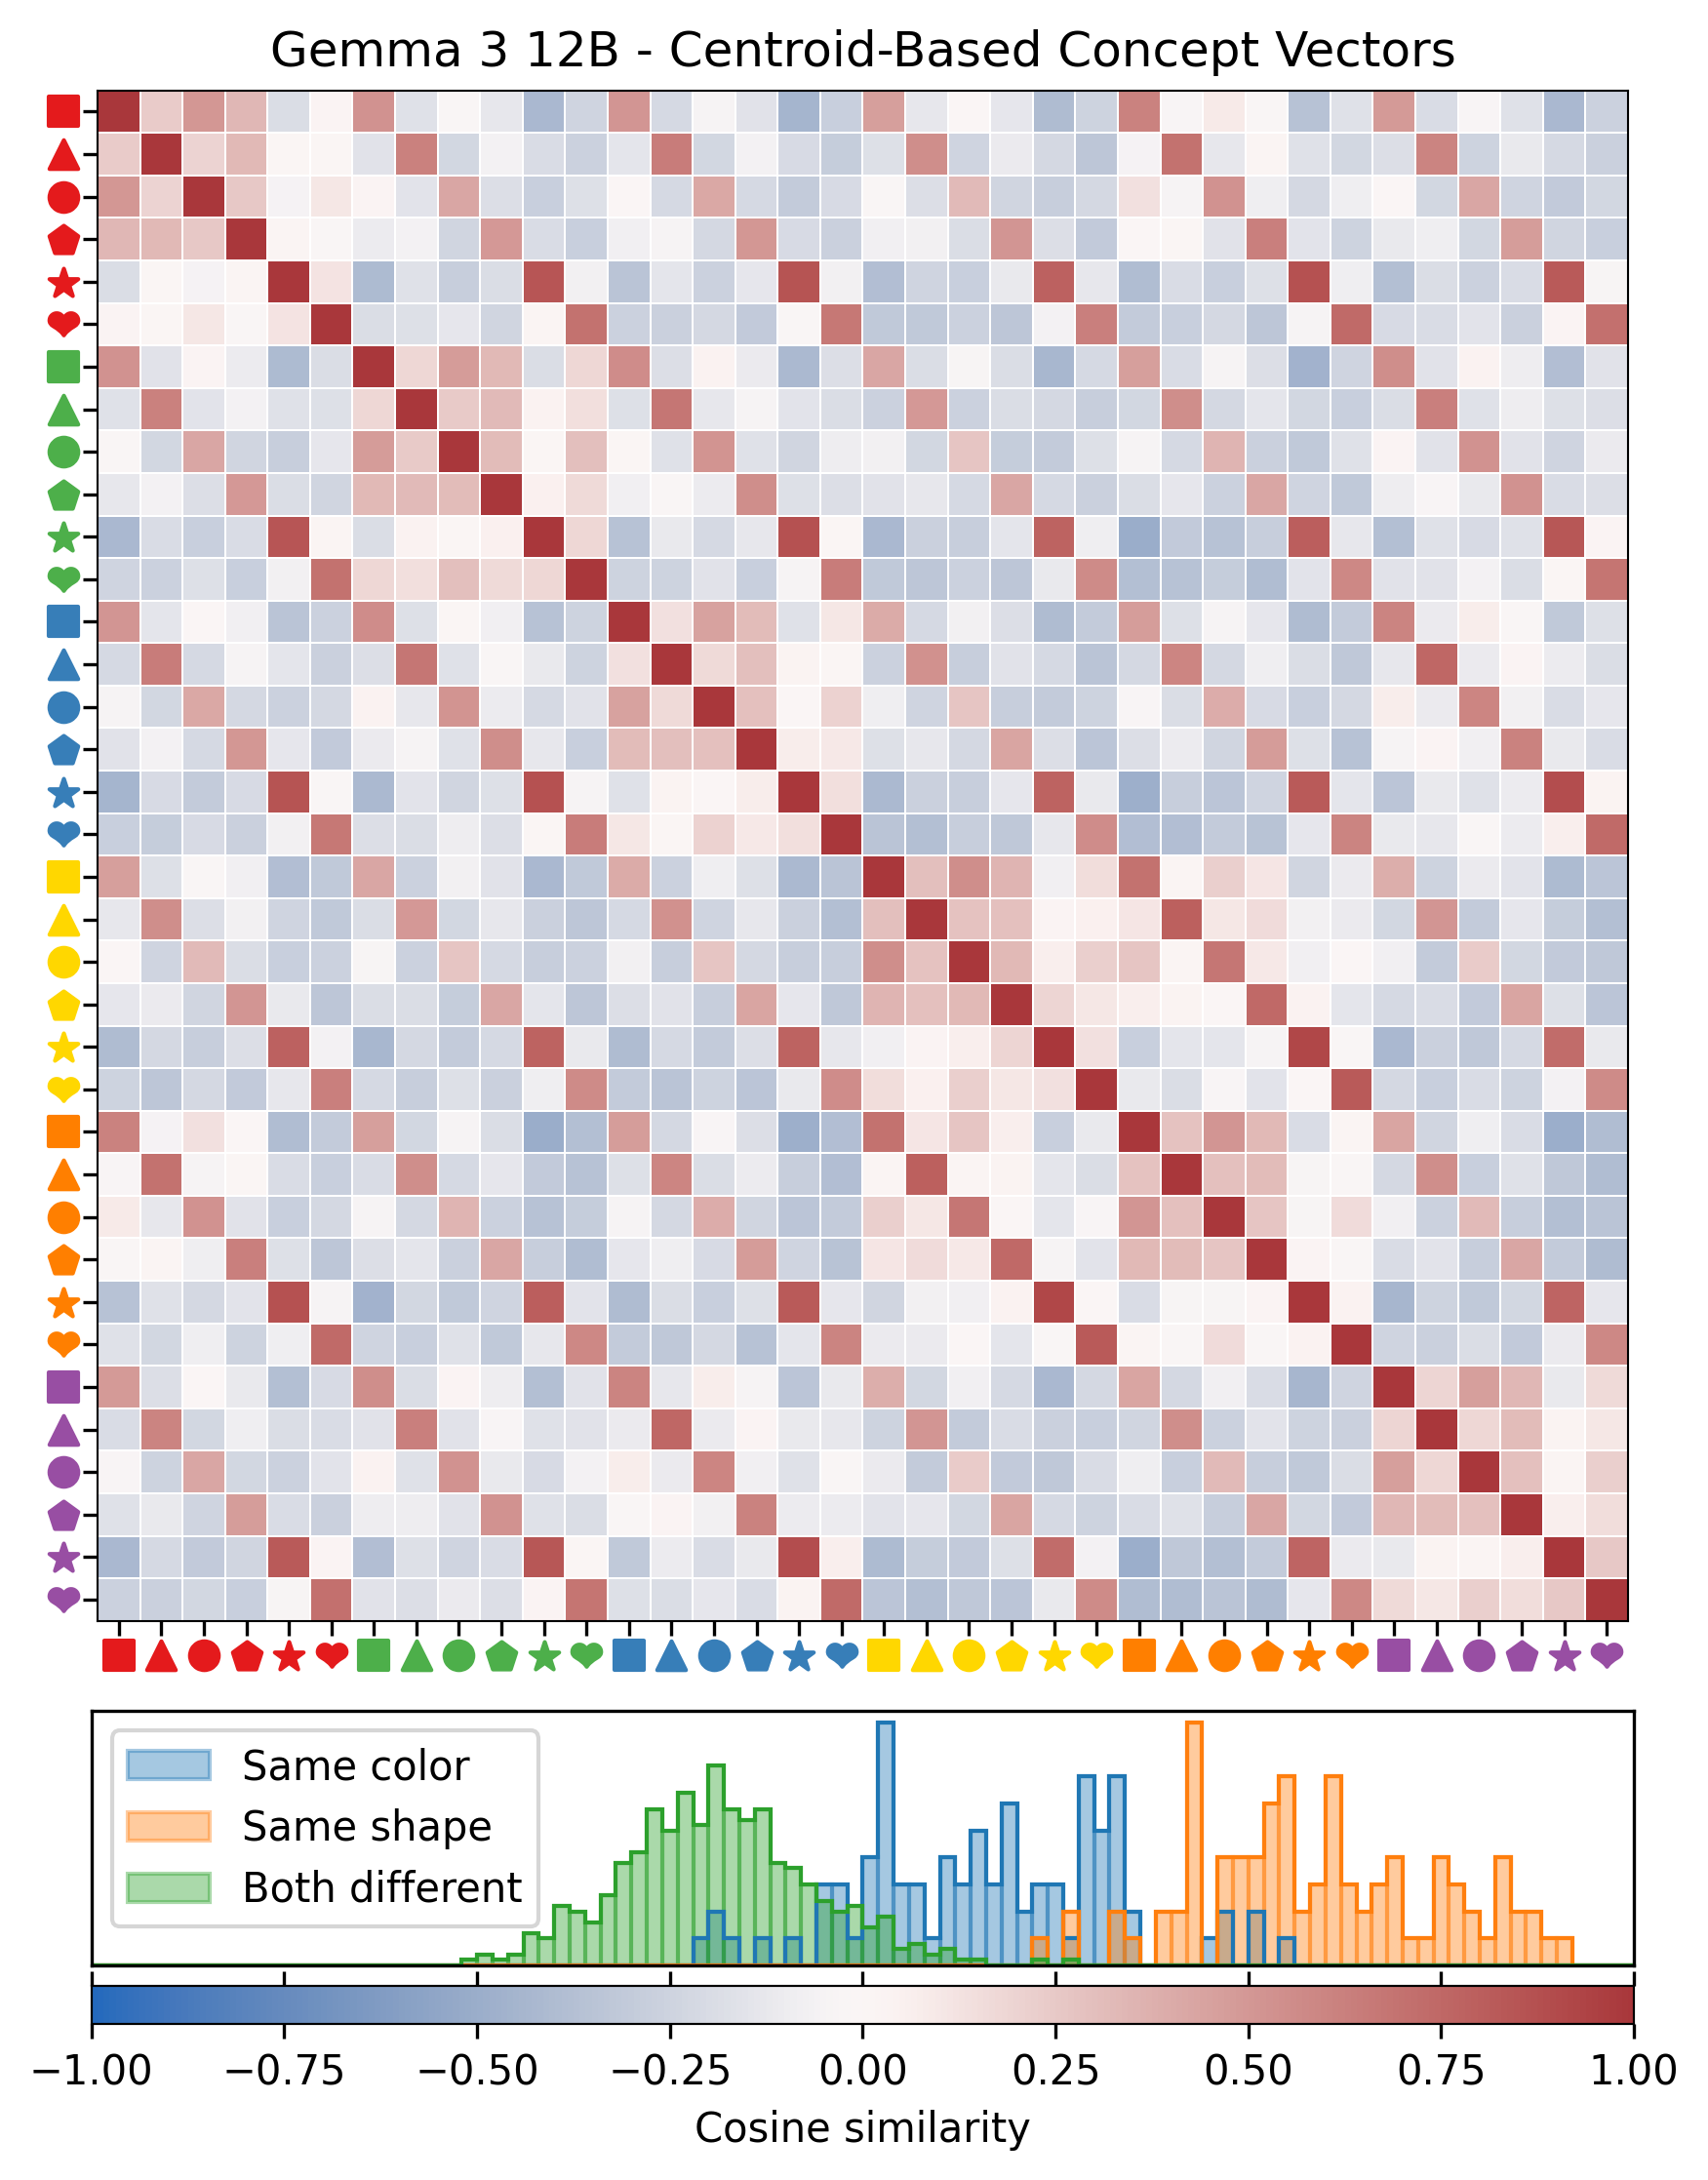

In [9]:
plt.close('all')
fig, ax = plotsims(sims,'centroid', model_name)

fig.savefig(f'./outputs/compositionality_plots/{model_name}_centroid_simmatrix.pdf',bbox_inches='tight')

#### Color concept vectors
Used in the steering experiments in section 4.1

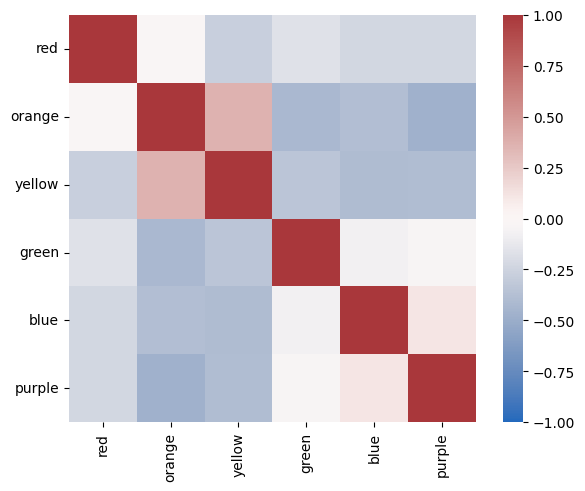

In [10]:
plt.close('all')
csims = simmatrix(color_cv[:6])
sns.heatmap(csims[[0,4,3,1,2,5],:][:,[0,4,3,1,2,5]],cmap='vlag',vmin=-1,square=True)
plt.yticks(torch.arange(6)+0.5,np.array(cfg.dataset.COLORS)[[0,4,3,1,2,5]],rotation='horizontal')
plt.xticks(torch.arange(6)+0.5,np.array(cfg.dataset.COLORS)[[0,4,3,1,2,5]],rotation='vertical')
plt.show()